In [1]:
# VAE for Fraud Detection
# Variational Autoencoder Anomaly Detection


import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score, 
    precision_recall_curve, precision_score, 
    recall_score, f1_score
)

# Set project root
try:
    current_dir = Path.cwd()
    if (current_dir / 'src').exists():
        PROJECT_ROOT = current_dir
    elif (current_dir.parent / 'src').exists():
        PROJECT_ROOT = current_dir.parent
    else:
        PROJECT_ROOT = Path.cwd().parent
except Exception:
    PROJECT_ROOT = Path.cwd()

print(f"Project root: {PROJECT_ROOT}")

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def load_processed_data(dataset='ieee'):
    data_dir = PROJECT_ROOT / 'data' / 'processed'
    train = pd.read_parquet(data_dir / f'{dataset}_train.parquet')
    test = pd.read_parquet(data_dir / f'{dataset}_test.parquet')
    with open(data_dir / 'dataset_info.json', 'r') as f:
        info = json.load(f)
    raw_cols = info[dataset]['raw_features']
    eng_cols = info[dataset]['engineered_features']
    all_cols = raw_cols + eng_cols
    return train, test, raw_cols, eng_cols, all_cols

train_ieee, test_ieee, raw_cols, eng_cols, all_cols = load_processed_data('ieee')

print(f"Total features: {len(all_cols)}")
print(f"Train shape: {train_ieee.shape}")
print(f"Test shape: {test_ieee.shape}")
print(f"Train fraud rate: {train_ieee['isFraud'].mean():.4f}")
print(f"Test fraud rate: {test_ieee['isFraud'].mean():.4f}")

# Feature Preparation

X_train_raw = train_ieee[all_cols].values
X_test_raw = test_ieee[all_cols].values
y_train = train_ieee['isFraud'].values
y_test = test_ieee['isFraud'].values

print(f"X_train shape: {X_train_raw.shape}")
print(f"X_test shape: {X_test_raw.shape}")

# Handle missing values
if np.isnan(X_train_raw).sum() > 0:
    print(f"Filling {np.isnan(X_train_raw).sum()} missing values...")
    for i in range(X_train_raw.shape[1]):
        col_median = np.nanmedian(X_train_raw[:, i])
        X_train_raw[np.isnan(X_train_raw[:, i]), i] = col_median
        X_test_raw[np.isnan(X_test_raw[:, i]), i] = col_median

# Standardize
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"X_train shape after scaling: {X_train.shape}")



Project root: /Users/mac/Desktop/DSS5104_Assignment2
Using device: cpu
Total features: 64
Train shape: (472432, 470)
Test shape: (118108, 470)
Train fraud rate: 0.0351
Test fraud rate: 0.0344
X_train shape: (472432, 64)
X_test shape: (118108, 64)
Filling 3433954 missing values...
X_train shape after scaling: (472432, 64)


In [2]:
# VAE Model

class VAE(nn.Module):
    """Variational Autoencoder"""
    def __init__(self, input_dim, latent_dim=16, hidden_dims=[128, 64]):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        
        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            encoder_layers.append(nn.Linear(prev_dim, h_dim))
            encoder_layers.append(nn.BatchNorm1d(h_dim))
            encoder_layers.append(nn.ReLU())
            encoder_layers.append(nn.Dropout(0.2))
            prev_dim = h_dim
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Mean and variance layers
        self.fc_mu = nn.Linear(hidden_dims[-1], latent_dim)
        self.fc_logvar = nn.Linear(hidden_dims[-1], latent_dim)
        
        # Decoder
        decoder_layers = []
        prev_dim = latent_dim
        for h_dim in reversed(hidden_dims):
            decoder_layers.append(nn.Linear(prev_dim, h_dim))
            decoder_layers.append(nn.BatchNorm1d(h_dim))
            decoder_layers.append(nn.ReLU())
            decoder_layers.append(nn.Dropout(0.2))
            prev_dim = h_dim
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)
    
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar
    
    def loss_function(self, recon, x, mu, logvar, beta=1.0):
        # Reconstruction loss (MSE)
        recon_loss = nn.functional.mse_loss(recon, x, reduction='sum')
        # KL divergence
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        # ELBO loss
        return (recon_loss + beta * kl_loss) / x.size(0)
    
    def get_anomaly_score(self, x, num_samples=10):
        """Compute anomaly score using reconstruction error + KL divergence"""
        self.eval()
        with torch.no_grad():
            mu, logvar = self.encode(x)
            # Sample multiple reconstructions
            recon_samples = []
            for _ in range(num_samples):
                z = self.reparameterize(mu, logvar)
                recon = self.decode(z)
                recon_samples.append(recon)
            recon_avg = torch.stack(recon_samples).mean(dim=0)
            # Reconstruction error
            recon_error = ((x - recon_avg) ** 2).mean(dim=1)
            # KL divergence as anomaly score component
            kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)
            # Combined score
            anomaly_score = recon_error + 0.1 * kl_div
        return anomaly_score.cpu().numpy()


class EnsembleVAE:
    """Ensemble VAE with multiple latent dimensions"""
    def __init__(self, input_dim, latent_dims=[8, 16, 32]):
        self.input_dim = input_dim
        self.latent_dims = latent_dims
        self.models = []
    
    def _train_single(self, X_train, latent_dim, epochs=100, batch_size=4096, beta=1.0, verbose=True):
        val_size = int(len(X_train) * 0.1)
        X_train_sub = torch.FloatTensor(X_train[:-val_size]).to(device)
        X_val = torch.FloatTensor(X_train[-val_size:]).to(device)
        
        train_dataset = TensorDataset(X_train_sub, X_train_sub)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        
        model = VAE(self.input_dim, latent_dim=latent_dim).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
        
        best_val_loss = float('inf')
        patience_counter = 0
        
        for epoch in range(epochs):
            model.train()
            epoch_loss = 0
            for batch_X, _ in train_loader:
                optimizer.zero_grad()
                recon, mu, logvar = model(batch_X)
                loss = model.loss_function(recon, batch_X, mu, logvar, beta=beta)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * batch_X.size(0)
            
            epoch_loss /= len(X_train_sub)
            
            model.eval()
            with torch.no_grad():
                recon, mu, logvar = model(X_val)
                val_loss = model.loss_function(recon, X_val, mu, logvar, beta=beta).item()
            
            scheduler.step(val_loss)
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_state = model.state_dict().copy()
            else:
                patience_counter += 1
            
            if patience_counter >= 15:
                break
            
            if verbose and (epoch + 1) % 20 == 0:
                print(f"  Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")
        
        model.load_state_dict(best_state)
        return model
    
    def fit(self, X_train, y_train, mode='semi_supervised', epochs=100, batch_size=4096, beta=1.0, verbose=True):
        if mode == 'semi_supervised':
            normal_idx = (y_train == 0)
            X_train_selected = X_train[normal_idx]
            print(f"Semi-supervised mode: {len(X_train_selected):,} normal samples")
        else:
            X_train_selected = X_train
            print(f"Supervised mode: {len(X_train_selected):,} all samples")
        
        self.models = []
        for i, lat_dim in enumerate(self.latent_dims):
            print(f"\nTraining latent dimension {lat_dim} ({i+1}/{len(self.latent_dims)})")
            model = self._train_single(X_train_selected, lat_dim, epochs, batch_size, beta, verbose)
            self.models.append(model)
        
        return self
    
    def predict_anomaly_scores(self, X, num_samples=10):
        X_tensor = torch.FloatTensor(X).to(device)
        all_scores = []
        for model in self.models:
            scores = model.get_anomaly_score(X_tensor, num_samples)
            all_scores.append(scores)
        return np.mean(all_scores, axis=0)



In [3]:
# Semi-supervised VAE

input_dim = X_train.shape[1]
print(f"Input dimension: {input_dim}")

print("="*60)
print("Training: Semi-supervised Ensemble VAE")
print("="*60)

vae_semi = EnsembleVAE(input_dim, latent_dims=[8, 16, 32])
vae_semi.fit(X_train, y_train, mode='semi_supervised', epochs=100, batch_size=4096, beta=1.0, verbose=True)

test_scores_semi = vae_semi.predict_anomaly_scores(X_test, num_samples=10)

auprc_semi = average_precision_score(y_test, test_scores_semi)
roc_auc_semi = roc_auc_score(y_test, test_scores_semi)

print(f"\nTest Results (Semi-supervised Ensemble VAE):")
print(f"  AUPRC: {auprc_semi:.4f}")
print(f"  ROC AUC: {roc_auc_semi:.4f}")

# Train Supervised VAE

print("="*60)
print("Training: Supervised Ensemble VAE")
print("="*60)

vae_sup = EnsembleVAE(input_dim, latent_dims=[8, 16, 32])
vae_sup.fit(X_train, y_train, mode='supervised', epochs=100, batch_size=4096, beta=1.0, verbose=True)

test_scores_sup = vae_sup.predict_anomaly_scores(X_test, num_samples=10)

auprc_sup = average_precision_score(y_test, test_scores_sup)
roc_auc_sup = roc_auc_score(y_test, test_scores_sup)

print(f"\nTest Results (Supervised Ensemble VAE):")
print(f"  AUPRC: {auprc_sup:.4f}")
print(f"  ROC AUC: {roc_auc_sup:.4f}")




Input dimension: 64
Training: Semi-supervised Ensemble VAE
Semi-supervised mode: 455,833 normal samples

Training latent dimension 8 (1/3)
  Epoch 20/100, Loss: 33.3338, Val Loss: 31.7599
  Epoch 40/100, Loss: 32.3884, Val Loss: 30.4702
  Epoch 60/100, Loss: 31.9315, Val Loss: 29.9608
  Epoch 80/100, Loss: 31.5654, Val Loss: 29.6789
  Epoch 100/100, Loss: 31.3970, Val Loss: 29.5909

Training latent dimension 16 (2/3)
  Epoch 20/100, Loss: 33.7107, Val Loss: 33.0405
  Epoch 40/100, Loss: 32.5809, Val Loss: 31.4652
  Epoch 60/100, Loss: 31.9357, Val Loss: 29.8136
  Epoch 80/100, Loss: 31.6175, Val Loss: 29.4352
  Epoch 100/100, Loss: 31.3734, Val Loss: 29.2299

Training latent dimension 32 (3/3)
  Epoch 20/100, Loss: 34.3387, Val Loss: 34.2582
  Epoch 40/100, Loss: 33.1149, Val Loss: 32.9137
  Epoch 60/100, Loss: 32.6605, Val Loss: 32.5804
  Epoch 80/100, Loss: 32.3762, Val Loss: 32.1248
  Epoch 100/100, Loss: 32.2269, Val Loss: 31.9716

Test Results (Semi-supervised Ensemble VAE):
  AUP

In [4]:
#  Evaluation with Cost-Optimal Threshold

optimal_threshold = 0.0708

def normalize_scores(scores):
    scores_min = scores.min()
    scores_max = scores.max()
    if scores_max - scores_min > 0:
        return (scores - scores_min) / (scores_max - scores_min)
    return scores

test_scores_semi_norm = normalize_scores(test_scores_semi)
test_scores_sup_norm = normalize_scores(test_scores_sup)

y_pred_semi = (test_scores_semi_norm > optimal_threshold).astype(int)
y_pred_sup = (test_scores_sup_norm > optimal_threshold).astype(int)

print("="*60)
print(f"Evaluation with Cost-Optimal Threshold ({optimal_threshold})")
print("="*60)

print(f"\nSemi-supervised VAE:")
print(f"  AUPRC: {auprc_semi:.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_semi):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_semi):.4f}")
print(f"  F1: {f1_score(y_test, y_pred_semi):.4f}")

print(f"\nSupervised VAE:")
print(f"  AUPRC: {auprc_sup:.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_sup):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_sup):.4f}")
print(f"  F1: {f1_score(y_test, y_pred_sup):.4f}")



Evaluation with Cost-Optimal Threshold (0.0708)

Semi-supervised VAE:
  AUPRC: 0.0518
  Precision: 0.0715
  Recall: 0.0118
  F1: 0.0203

Supervised VAE:
  AUPRC: 0.0493
  Precision: 0.0424
  Recall: 0.0069
  F1: 0.0119


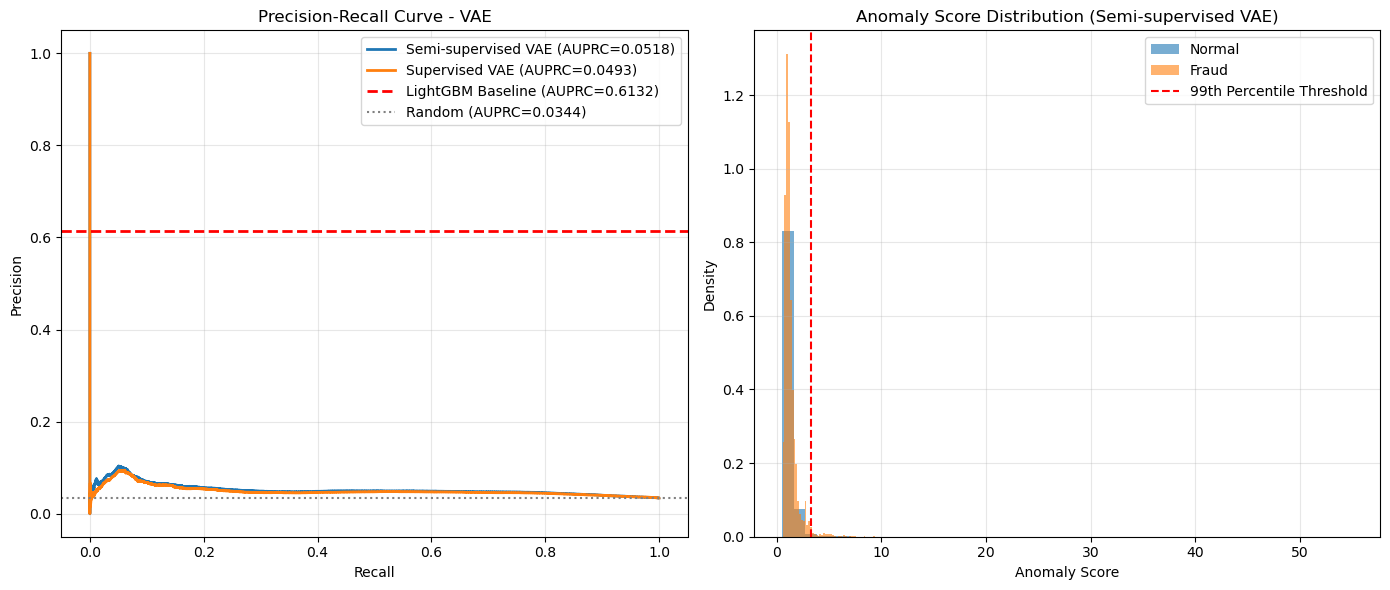

In [5]:
# Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PR Curves
precision_semi, recall_semi, _ = precision_recall_curve(y_test, test_scores_semi_norm)
precision_sup, recall_sup, _ = precision_recall_curve(y_test, test_scores_sup_norm)

axes[0].plot(recall_semi, precision_semi, linewidth=2, 
             label=f'Semi-supervised VAE (AUPRC={auprc_semi:.4f})')
axes[0].plot(recall_sup, precision_sup, linewidth=2,
             label=f'Supervised VAE (AUPRC={auprc_sup:.4f})')
axes[0].axhline(y=0.6132, color='red', linestyle='--', linewidth=2,
                label=f'LightGBM Baseline (AUPRC=0.6132)')
axes[0].axhline(y=y_test.mean(), color='gray', linestyle=':', linewidth=1.5,
                label=f'Random (AUPRC={y_test.mean():.4f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve - VAE')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Anomaly Score Distribution
axes[1].hist(test_scores_semi[y_test==0], bins=50, alpha=0.6, label='Normal', density=True)
axes[1].hist(test_scores_semi[y_test==1], bins=50, alpha=0.6, label='Fraud', density=True)
threshold_99 = np.percentile(test_scores_semi[y_test==0], 99)
axes[1].axvline(x=threshold_99, color='red', linestyle='--', label=f'99th Percentile Threshold')
axes[1].set_xlabel('Anomaly Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Anomaly Score Distribution (Semi-supervised VAE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed' / 'vae_results.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# Results Summary

results_summary = pd.DataFrame({
    'Model': [
        'Semi-supervised VAE',
        'Supervised VAE',
        'Semi-supervised Autoencoder',
        'Supervised Autoencoder',
        'Supervised Neural Network',
        'LightGBM Baseline'
    ],
    'AUPRC': [
        auprc_semi,
        auprc_sup,
        0.0547,  # Previous autoencoder semi result
        0.0547,  # Previous autoencoder sup result
        0.5157,  # Previous supervised NN result
        0.6132
    ]
})

print("\n" + "="*60)
print("Results Summary - VAE vs Baselines")
print("="*60)
print(results_summary.to_string(index=False))



Results Summary - VAE vs Baselines
                      Model    AUPRC
        Semi-supervised VAE 0.051751
             Supervised VAE 0.049266
Semi-supervised Autoencoder 0.054700
     Supervised Autoencoder 0.054700
  Supervised Neural Network 0.515700
          LightGBM Baseline 0.613200
